# Data Preparation & Random Forest — a worked example

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/SCAI-4EUWorkshopAIinMedicineWorkshop/blob/main/Hands-On-Session-1/data_preparation_example.ipynb)

## Objective

Real-world medical data is rarely clean — it has **missing values**, **outliers**, and
**categorical variables** that all need preprocessing before any model can learn from it.

Here we work with a noised version of the **Breast Cancer Wisconsin** dataset (diagnose a
tumor as *malignant* or *benign*) and walk through the full workflow:

> **Explore → Visualize → Prepare → Train → Evaluate**

1. Discover the data's quality problems.
2. Learn the **data-preparation pipeline**: imputation → outlier handling → encoding → scaling.
3. Train a **Random Forest** and compare it against a logistic-regression baseline.

**Key idea:** on messy data, careful preparation usually matters more than the choice of model.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             ConfusionMatrixDisplay)

## 2. Load & Explore the Data

This dataset is built to look like **real clinical data**:

- some measurements are **missing** (equipment errors, incomplete records),
- some contain **outliers** (data-entry mistakes, extreme cases),
- there are **categorical** columns (patient demographics).

Your first job as a data scientist is to **discover and understand these issues** before any
modeling.

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/racousin/SCAI-4EUWorkshopAIinMedicineWorkshop/main/Hands-On-Session-1/breast_cancer_noisy.csv")

# Target: 0 = malignant, 1 = benign
target_names = np.array(["malignant", "benign"])

# Split columns by type (the target is excluded from the feature lists)
numeric_cols     = df.select_dtypes(include=[np.number]).columns.drop("target").tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print(f"Shape: {df.shape}")
print(f"{len(numeric_cols)} numeric features")
print(f"{len(categorical_cols)} categorical features: {categorical_cols}")
df.head()

Shape: (569, 34)
30 numeric features
3 categorical features: ['age_group', 'menopause_status', 'tumor_location']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,age_group,menopause_status,tumor_location
0,17.990000,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,0.1622,0.6656,0.7119,0.2654,0.4601,NaN,0,middle,pre,upper_inner
1,20.570000,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,0.1238,0.1866,0.2416,0.1860,NaN,0.08902,0,old,post,upper_inner
2,19.690000,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,old,post,central
3,87.142752,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,NaN,0.09744,...,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,middle,pre,upper_outer
4,20.290000,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,NaN,0.05883,...,0.1374,NaN,0.4000,0.1625,0.2364,0.07678,0,young,pre,lower_outer


Use `.info()` (types + non-null counts) and `.describe()` (value ranges) to spot the three
classic problems: **missing values**, **outliers** (suspiciously large max values), and
**categorical** (non-numeric) columns.

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              543 non-null    float64
 1   mean texture             536 non-null    float64
 2   mean perimeter           542 non-null    float64
 3   mean area                544 non-null    float64
 4   mean smoothness          545 non-null    float64
 5   mean compactness         541 non-null    float64
 6   mean concavity           533 non-null    float64
 7   mean concave points      530 non-null    float64
 8   mean symmetry            542 non-null    float64
 9   mean fractal dimension   544 non-null    float64
 10  radius error             546 non-null    float64
 11  texture error            527 non-null    float64
 12  perimeter error          544 non-null    float64
 13  area error               534 non-null    float64
 14  smoothness error         5

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,543.000000,536.000000,542.000000,544.000000,545.000000,541.000000,533.000000,530.000000,542.000000,544.000000,...,547.000000,538.000000,547.000000,545.000000,542.000000,548.000000,546.000000,536.000000,534.000000,569.000000
mean,16.475067,19.240784,91.828672,717.533486,0.096213,0.104319,0.090298,0.049291,0.180937,0.062779,...,25.562029,107.193234,872.234369,0.132556,0.254076,0.274202,0.115195,0.290810,0.084082,0.627417
std,15.268090,4.251682,24.562463,590.504934,0.014050,0.053341,0.080744,0.038850,0.026819,0.007058,...,6.088038,33.291238,558.893474,0.022867,0.157070,0.209434,0.066060,0.062362,0.018105,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.116700,0.049960,...,12.020000,50.410000,185.200000,0.081250,0.027290,0.000000,0.000000,0.156600,0.055040,0.000000
25%,11.755000,16.170000,74.690000,426.525000,0.085970,0.063760,0.029950,0.020362,0.161900,0.057697,...,20.970000,84.430000,515.550000,0.116600,0.147725,0.115925,0.064943,0.250475,0.071857,0.000000
50%,13.500000,18.785000,85.935000,561.700000,0.095660,0.092280,0.061950,0.033950,0.178950,0.061515,...,25.400000,97.745000,684.500000,0.131400,0.213000,0.229800,0.100550,0.282800,0.080075,1.000000
75%,16.255000,21.735000,104.025000,816.275000,0.105100,0.130500,0.132400,0.074632,0.195400,0.066090,...,29.420000,125.325000,1047.000000,0.146300,0.334150,0.385500,0.162500,0.318850,0.092075,1.000000
max,176.072082,39.280000,188.500000,7399.774357,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [4]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

Missing values per column:
mean radius                26
mean texture               33
mean perimeter             27
mean area                  25
mean smoothness            24
mean compactness           28
mean concavity             36
mean concave points        39
mean symmetry              27
mean fractal dimension     25
radius error               23
texture error              42
perimeter error            25
area error                 35
smoothness error           35
compactness error          27
concavity error            30
concave points error       33
symmetry error             24
fractal dimension error    31
worst radius               33
worst texture              22
worst perimeter            31
worst area                 22
worst smoothness           24
worst compactness          27
worst concavity            21
worst concave points       23
worst symmetry             33
worst fractal dimension    35
dtype: int64

Total missing cells: 866


## 3. Visualize the Data Issues

Before fixing problems, we need to **see** them.

### 3.1 — Where are the missing values?

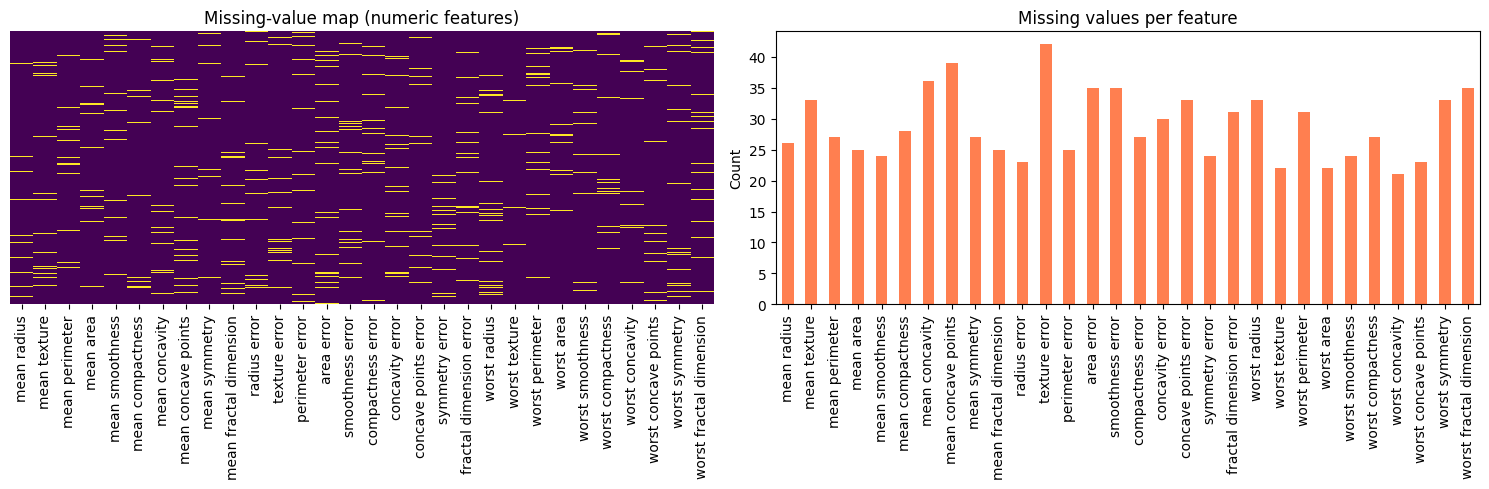

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(df[numeric_cols].isnull(), cbar=False, yticklabels=False, ax=axes[0], cmap="viridis")
axes[0].set_title("Missing-value map (numeric features)")
axes[0].tick_params(axis="x", rotation=90)

df[numeric_cols].isnull().sum().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Missing values per feature")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### 3.2 — Outliers

Boxplots show the median, the quartiles, and **outliers** (points beyond 1.5×IQR). `mean
radius` and `mean area` have a clear tail of extreme values.

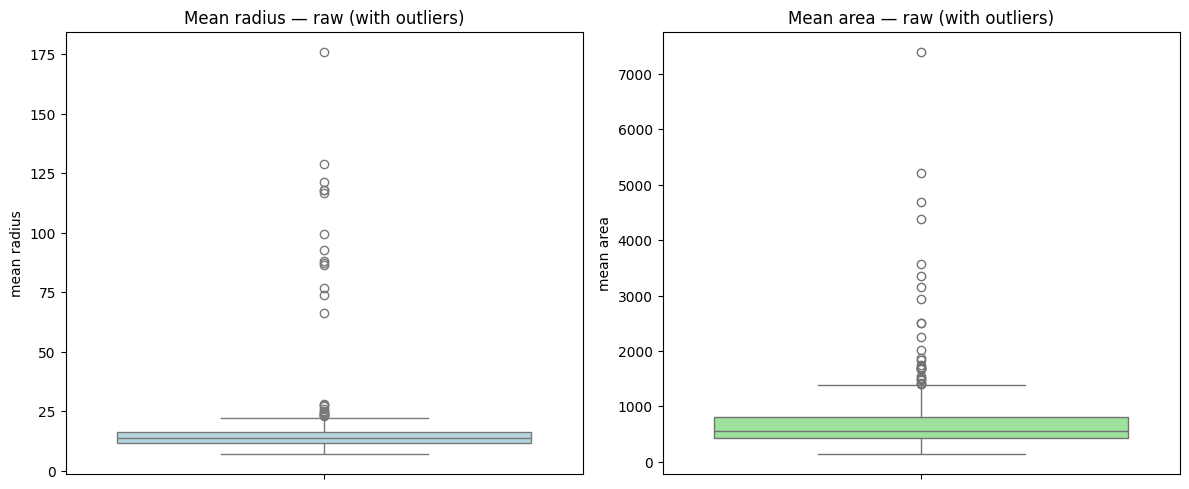

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df["mean radius"], ax=axes[0], color="lightblue")
axes[0].set_title("Mean radius — raw (with outliers)")
sns.boxplot(y=df["mean area"], ax=axes[1], color="lightgreen")
axes[1].set_title("Mean area — raw (with outliers)")
plt.tight_layout()
plt.show()

### 3.3 — Distribution of the categorical features

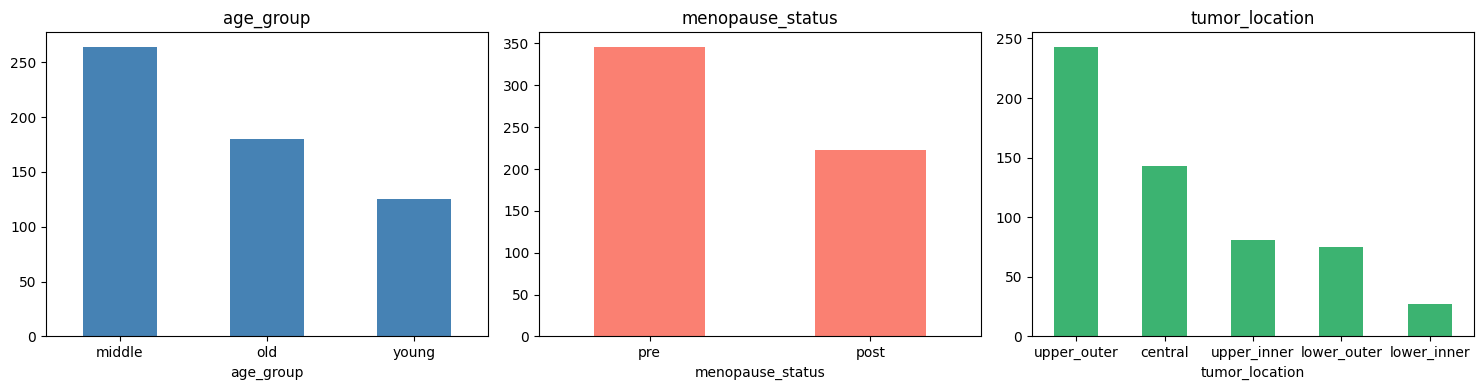

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, categorical_cols, ["steelblue", "salmon", "mediumseagreen"]):
    df[col].value_counts().plot(kind="bar", ax=ax, color=color)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 4. Handle Missing Values

Most models cannot train on `NaN`, so we fill the gaps with `SimpleImputer`:

| Strategy | When to use |
|---|---|
| Drop rows | Very few missing values, large dataset |
| **Median** imputation | Numeric features (robust to outliers) |
| **Most-frequent** imputation | Categorical features |

We use **median** for numeric columns (robust to the outliers we just saw) and
**most-frequent** for categorical columns.

In [8]:
num_imputer = SimpleImputer(strategy="median")
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("Total missing values after imputation:", int(df.isnull().sum().sum()))

Total missing values after imputation: 0


## 5. Handle Outliers

Outliers can distort training. We detect them with the **IQR method** and **clip** them to
the bounds:

- **IQR** = Q3 − Q1
- **lower** = Q1 − 1.5·IQR, **upper** = Q3 + 1.5·IQR
- values outside `[lower, upper]` are set to the nearest bound.

**Why clip instead of drop?** In medical data every patient matters — clipping keeps the
sample while taming the extreme value.

In [9]:
print("Before clipping:")
print(f"  mean radius  max = {df['mean radius'].max():.2f}")
print(f"  mean area    max = {df['mean area'].max():.2f}")

for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

print("\nAfter clipping:")
print(f"  mean radius  max = {df['mean radius'].max():.2f}")
print(f"  mean area    max = {df['mean area'].max():.2f}")

Before clipping:
  mean radius  max = 176.07
  mean area    max = 7399.77

After clipping:
  mean radius  max = 22.55
  mean area    max = 1359.90


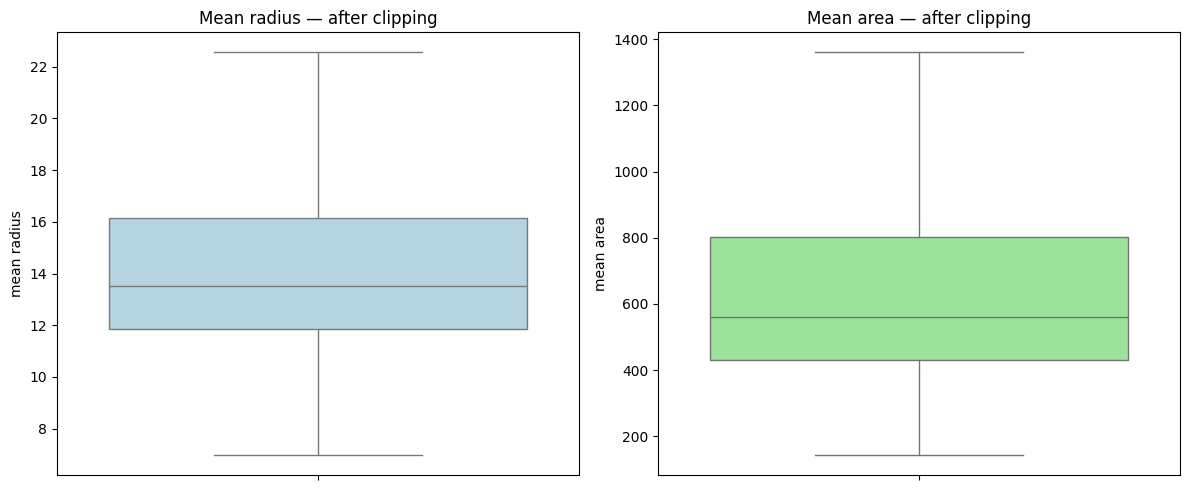

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df["mean radius"], ax=axes[0], color="lightblue")
axes[0].set_title("Mean radius — after clipping")
sns.boxplot(y=df["mean area"], ax=axes[1], color="lightgreen")
axes[1].set_title("Mean area — after clipping")
plt.tight_layout()
plt.show()

## 6. Encode Categorical Features

Models work with **numbers**, not text. **One-hot encoding** creates one binary column per
category:

| tumor_location | → | central | lower_inner | upper_inner |
|---|---|---|---|---|
| upper_inner | | 0 | 0 | 1 |
| central     | | 1 | 0 | 0 |

**Why not just number the categories (0, 1, 2)?** That would imply an **order** between them,
which usually isn't meaningful. `drop_first=True` removes one redundant column per feature
(the *dummy-variable trap*).

In [ ]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
new_cols = [c for c in df.columns if c not in numeric_cols and c != "target"]
print(f"Shape after encoding: {df.shape}")
print(f"New one-hot columns: {new_cols}")
df.head()

## 7. Split & Scale

Separate features `X` from the target `y`, hold out 20% for testing, then standardize each
feature to mean 0 / std 1:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

**Crucial:** fit the scaler on the **training set only**, then apply it to both — otherwise
information from the test set leaks into training.

In [13]:
categorical_cols = ['age_group', 'menopause_status', 'tumor_location']

# Ensure categorical columns are one-hot encoded before splitting
# This step ensures that X will only contain numerical features.
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop("target", axis=1)
y = df_encoded["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train
X_test_scaled  = scaler.transform(X_test)        # apply to test

print(f"Train: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]} samples")

Train: 455 samples, 37 features
Test:  114 samples


## 8. Baseline: Logistic Regression

Always start with a **simple, well-understood model**. Its score is the reference any fancier
model must beat.

In [14]:
lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print(f"Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print(classification_report(y_test, y_pred_lr, target_names=target_names))

Logistic Regression accuracy: 0.9649

              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



## 9. Random Forest

A **Random Forest** is an **ensemble** of many **decision trees**, each trained on a random
subset of the rows and features. The final prediction is the **majority vote** of all trees;
because the trees make *different* errors, the errors tend to cancel out.

| Property | Logistic Regression | Random Forest |
|---|---|---|
| Decision boundary | Linear | Non-linear |
| Sensitive to scale / outliers | Yes | No |
| Interpretability | Coefficients | Feature importances |

> **Medical analogy:** like asking several doctors — the consensus is usually more reliable
> than any single opinion.

In [15]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print(f"Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest accuracy:       {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

Logistic Regression accuracy: 0.9649
Random Forest accuracy:       0.9386

              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



### 9.1 — Compare the confusion matrices

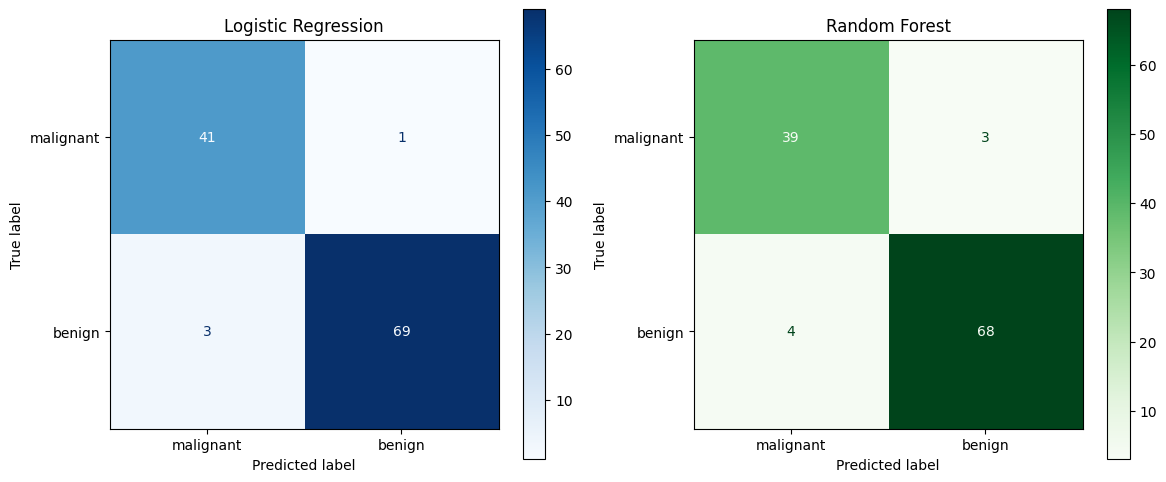

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=target_names,
                                        cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=target_names,
                                        cmap="Greens", ax=axes[1])
axes[1].set_title("Random Forest")
plt.tight_layout()
plt.show()

### 9.2 — Feature importances

A Random Forest reports how much each feature contributed — valuable for understanding *what
drives the diagnosis*.

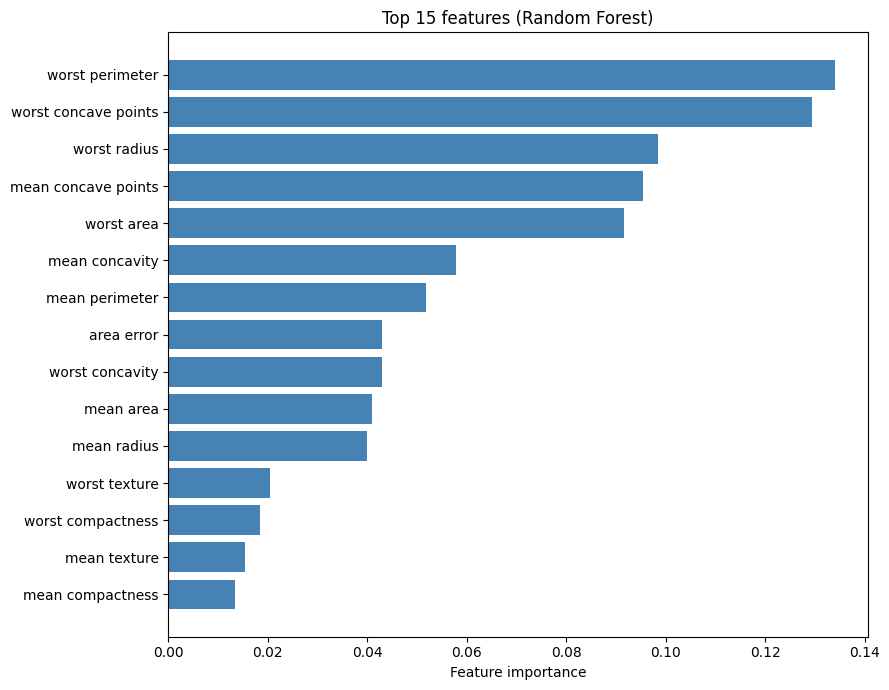

In [17]:
importances = rf.feature_importances_
order = np.argsort(importances)[-15:]

plt.figure(figsize=(9, 7))
plt.barh(range(len(order)), importances[order], color="steelblue")
plt.yticks(range(len(order)), X.columns[order])
plt.xlabel("Feature importance")
plt.title("Top 15 features (Random Forest)")
plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning

Hyperparameters are settings we choose **before** training. `GridSearchCV` tries every
combination and keeps the best one, scored by cross-validation.

| Hyperparameter | Controls | Too low | Too high |
|---|---|---|---|
| `n_estimators` | Number of trees | Unstable | Slow, diminishing returns |
| `max_depth` | Tree depth | Underfit | Overfit (memorizes noise) |
| `min_samples_split` | Samples needed to split | Overfit | Underfit |

In [19]:
param_grid = {
    "n_estimators": [100, 150,200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
}
grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.4f}")

y_pred_best = grid.best_estimator_.predict(X_test_scaled)
print(f"\nDefault RF test accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Tuned   RF test accuracy: {accuracy_score(y_test, y_pred_best):.4f}")

Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV accuracy: 0.9582

Default RF test accuracy: 0.9386
Tuned   RF test accuracy: 0.9386


## 11. Cross-Validation Comparison

A single train/test split can be lucky or unlucky. **5-fold cross-validation** rotates the
test fold through all the data for a more reliable estimate. We wrap scaling and the model in
a `Pipeline` so the scaler is re-fit on each fold's training portion only — **no leakage**.

In [20]:
lr_pipe = Pipeline([("scale", StandardScaler()),
                    ("model", LogisticRegression(max_iter=5000, random_state=42))])
rf_pipe = Pipeline([("scale", StandardScaler()),
                    ("model", grid.best_estimator_)])

lr_scores = cross_val_score(lr_pipe, X, y, cv=5, scoring="accuracy")
rf_scores = cross_val_score(rf_pipe, X, y, cv=5, scoring="accuracy")

print(f"{'Model':<24}{'Accuracy':>10}{'Std':>10}")
print("-" * 44)
print(f"{'Logistic Regression':<24}{lr_scores.mean():>10.4f}{lr_scores.std():>10.4f}")
print(f"{'Random Forest (tuned)':<24}{rf_scores.mean():>10.4f}{rf_scores.std():>10.4f}")

Model                     Accuracy       Std
--------------------------------------------
Logistic Regression         0.9631    0.0116
Random Forest (tuned)       0.9473    0.0248


## 12. Summary

| Step | Technique | Why |
|---|---|---|
| Missing values | `SimpleImputer` (median / most-frequent) | Fill `NaN` without dropping samples |
| Outliers | IQR clipping | Tame extreme values, keep the sample |
| Categorical encoding | One-hot (`get_dummies`) | Turn text categories into numbers |
| Feature scaling | `StandardScaler` | Put features on a common scale |
| Baseline | Logistic Regression | A reference score to beat |
| Stronger model | Random Forest | Ensemble of trees — captures non-linear patterns |
| Tuning | `GridSearchCV` | Find good hyperparameters via cross-validation |

```
Raw data → impute → handle outliers → encode → scale → split → train → evaluate
```

**Key insight:** data preparation is often more important than model choice. A well-prepared
dataset with a simple model frequently beats a complex model on messy data.